In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

data = pd.read_csv('data.csv', encoding='cp1252')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19484\3206612274.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data.csv', encoding='cp1252')


In [2]:
x=pd.to_numeric(data["no2"], errors="coerce")
x = x.dropna().values

In [3]:
print("Valid NO2 samples:", len(x))

Valid NO2 samples: 419509


In [5]:
r=102317129

ar = 0.05 * (r % 7)
br = 0.3 * ((r % 5) + 1)
print("a_r =", ar)
print("b_r =", br)

z = x + ar * np.sin(br * x)

a_r = 0.25
b_r = 1.5


In [6]:
mu =np.mean(z)
sigma_squared= np.mean((z - mu) ** 2)
lam =1/(2 * sigma_squared)
c =math.sqrt(lam / math.pi)

print("Learned Parameters")
print("mu =", mu)
print("lambda =", lam)
print("c =", c)

Learned Parameters
mu = 25.818063543032295
lambda = 0.0014617052940514906
c = 0.021570239817484047


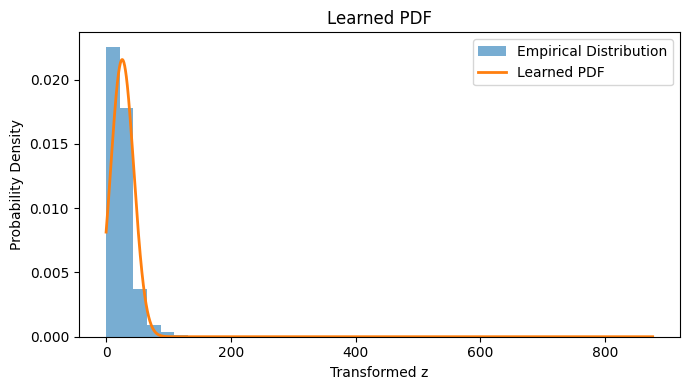

In [8]:
z_sorted=np.sort(z)
pdf_values =c * np.exp(-lam *(z_sorted -mu)**2)
plt.figure(figsize=(7, 4))
plt.hist(z, bins=40, density=True, alpha=0.6, label="Empirical Distribution")
plt.plot(z_sorted, pdf_values, linewidth=2, label="Learned PDF")

plt.xlabel("Transformed z")
plt.ylabel("Probability Density")
plt.title("Learned PDF")
plt.legend()
plt.tight_layout()
plt.show()